In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from imblearn.pipeline import Pipeline as ImbPipeline

import numpy as np
import seaborn as sns
import pandas as pd
import sys
import os
import shap
import sys
import os

e:\Projects\dc_model_ts\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sys.path.insert(0, os.path.abspath("../.."))
from src.pipeline import run_etl
from src.pipeline import DOMINIOS
from src.modeling import seed, train_model, get_confusion_matrix
df_tabla_0_imp, df_tabla_1_imp, df_mean, df_median = run_etl("../../.env")

Descargando datos desde GitHub...
Hojas cargadas: 125
Tabla 0 (escolaridad baja) : 36
Tabla 1 (escolaridad alta) : 81
No determinadas            : 8
df_tabla_0 crudo : (36, 32)
df_tabla_1 crudo : (81, 29)

 Imputando nulos...
--- Perfil nulos Tabla 0 ---
                                         nulos  %_nulos dtype  n_unicos
fluidez_verbal_semantica                    23    63.89   str         4
matrices                                    12    33.33   str         4
imagenes_sobrepuestas                       11    30.56   str         3
stroop_interferencia                         9    25.00   str         4
material_verbal_complejo                     6    16.67   str         3
denominacion                                 5    13.89   str         1
stroop_palabra                               4    11.11   str         4
stroop_color                                 4    11.11   str         4
atencion_sostenida_visual                    4    11.11   str         4
evocacion_diferida       

In [3]:
models = {
    'SVC LINEAR': SVC(kernel='linear', class_weight='balanced', C=0.1, gamma='scale', random_state=seed),
    'Random Forest': RandomForestClassifier(max_depth=4, n_estimators=200, min_samples_leaf=1, class_weight='balanced', max_features='sqrt', random_state=seed),
    'SVC RBF': SVC(kernel='rbf', C=10, gamma=0.01, class_weight='balanced', random_state=seed),
    'Logistic Regression': LogisticRegression(class_weight="balanced",max_iter=2000, random_state=seed)
}

In [4]:
#Features para el modelo

DOMINIOS_COGNITIVOS = list(DOMINIOS.keys())
features = [col for col in df_mean.columns if col != "dc"]

X_mean = df_mean[features]
y_mean = pd.to_numeric(df_mean["dc"], errors='coerce').fillna(-1).astype(int)

X_median = df_median[features]
y_median = pd.to_numeric(df_median["dc"], errors='coerce').fillna(-1).astype(int)


In [5]:
# Configuración de la validación cruzada estratificada repetida / debido a la naturaleza desbalanceada de las clases
cv_repeated_kfold = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=seed
) 
#Configuración de la validación cruzada estratificada / debido a la naturaleza desbalanceada de las clases
cv_kfold= StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

In [6]:
# Resultados
results = []
results_overfitting = []

for model_name, model in models.items():
    cv_scores = train_model(model, X_mean, y_mean, cv_repeated_kfold)

    # medias para calcular la brecha entre entrenamiento y validación/test, para detectar sobreentrenamiento
    train_f1 = cv_scores['train_f1_macro'].mean()
    test_f1 = cv_scores['test_f1_macro'].mean()
    train_balanced_accuracy = cv_scores['train_balanced_accuracy'].mean()
    test_balanced_accuracy = cv_scores['test_balanced_accuracy'].mean()
    train_sens_control = cv_scores['train_sens_control'].mean()
    test_sens_control = cv_scores['test_sens_control'].mean()
    train_sens_dcl = cv_scores['train_sens_dcl'].mean()
    test_sens_dcl = cv_scores['test_sens_dcl'].mean()
    train_sens_demencia = cv_scores['train_sens_demencia'].mean()
    test_sens_demencia = cv_scores['test_sens_demencia'].mean()

    results_overfitting.append({
        "Modelo": model_name,
        "F1 (Entrenamiento)": train_f1,
        "F1 (Validación / Test)": test_f1,
        # Si la brecha es muy grande (> 0.15), hay sobreentrenamiento
        "Brecha (Caída)": train_f1 - test_f1,
        "F1 Validación (Std)": cv_scores['test_f1_macro'].std()
    })
    
    # Calcular y almacenar las medias y desviaciones estándar
    results.append({
        "Modelo": model_name,
        "F1-Score Macro": test_f1,
        "F1-Score (Std)": cv_scores['test_f1_macro'].std(),
        "Balanced Accuracy": cv_scores['test_balanced_accuracy'].mean(),
        "Bal. Acc. (Std)": cv_scores['test_balanced_accuracy'].std(),
        "Sensibilidad Control": cv_scores['test_sens_control'].mean(),
        "Sensibilidad DCL": cv_scores['test_sens_dcl'].mean(),
        "Sensibilidad Demencia": cv_scores['test_sens_demencia'].mean(),
        "Especificidad Control": cv_scores['test_spec_control'].mean(),
        "Especificidad DCL": cv_scores['test_spec_dcl'].mean(),
        "Especificidad Demencia": cv_scores['test_spec_demencia'].mean()
    })


# Resultados, ordenados de mejor a peor
df_results = pd.DataFrame(results).sort_values(by="F1-Score Macro", ascending=False)
print("Resultados de los modelos")
print("-" * 70)
display(df_results.round(4))

# Resultados del overfitting
df_overfit = pd.DataFrame(results_overfitting).sort_values(by="F1 (Validación / Test)", ascending=False)
print("Analisis de overfitting")
print("-" * 85)
display(df_overfit.round(4))

Resultados de los modelos
----------------------------------------------------------------------


,Modelo,F1-Score Macro,F1-Score (Std),Balanced Accuracy,Bal. Acc. (Std),Sensibilidad Control,Sensibilidad DCL,Sensibilidad Demencia,Especificidad Control,Especificidad DCL,Especificidad Demencia
0,SVC LINEAR,0.7883,0.0760,0.8028,0.0734,0.8220,0.7342,0.8521,0.9144,0.8380,0.9088
1,Random Forest,0.7759,0.0849,0.7877,0.0880,0.8110,0.7365,0.8157,0.9294,0.8136,0.8947
2,SVC RBF,0.7605,0.0853,0.7698,0.0846,0.7917,0.7271,0.7905,0.9144,0.7912,0.9041
3,Logistic Regression,0.7418,0.0852,0.7569,0.0875,0.8160,0.6941,0.7605,0.9011,0.7862,0.8958


Analisis de overfitting
-------------------------------------------------------------------------------------


,Modelo,F1 (Entrenamiento),F1 (Validación / Test),Brecha (Caída),F1 Validación (Std)
0,SVC LINEAR,0.8566,0.7883,0.0684,0.0760
1,Random Forest,0.9310,0.7759,0.1551,0.0849
2,SVC RBF,0.8877,0.7605,0.1272,0.0853
3,Logistic Regression,0.8925,0.7418,0.1507,0.0852


In [7]:
# Resultados
results = []
results_overfitting = []

for model_name, model in models.items():
    cv_scores = train_model(model, X_median, y_median, cv_repeated_kfold)

    # medias para calcular la brecha entre entrenamiento y validación/test, para detectar sobreentrenamiento
    train_f1 = cv_scores['train_f1_macro'].mean()
    test_f1 = cv_scores['test_f1_macro'].mean()
    train_balanced_accuracy = cv_scores['train_balanced_accuracy'].mean()
    test_balanced_accuracy = cv_scores['test_balanced_accuracy'].mean()
    train_sens_control = cv_scores['train_sens_control'].mean()
    test_sens_control = cv_scores['test_sens_control'].mean()
    train_sens_dcl = cv_scores['train_sens_dcl'].mean()
    test_sens_dcl = cv_scores['test_sens_dcl'].mean()
    train_sens_demencia = cv_scores['train_sens_demencia'].mean()
    test_sens_demencia = cv_scores['test_sens_demencia'].mean()

    results_overfitting.append({
        "Modelo": model_name,
        "F1 (Entrenamiento)": train_f1,
        "F1 (Validación / Test)": test_f1,
        # Si la brecha es muy grande (> 0.15), hay sobreentrenamiento
        "Brecha (Caída)": train_f1 - test_f1,
        "F1 Validación (Std)": cv_scores['test_f1_macro'].std()
    })
    
    # Calcular y almacenar las medias y desviaciones estándar
    results.append({
        "Modelo": model_name,
        "F1-Score Macro": test_f1,
        "F1-Score (Std)": cv_scores['test_f1_macro'].std(),
        "Balanced Accuracy": cv_scores['test_balanced_accuracy'].mean(),
        "Bal. Acc. (Std)": cv_scores['test_balanced_accuracy'].std(),
        "Sensibilidad Control": cv_scores['test_sens_control'].mean(),
        "Sensibilidad DCL": cv_scores['test_sens_dcl'].mean(),
        "Sensibilidad Demencia": cv_scores['test_sens_demencia'].mean(),
        "Especificidad Control": cv_scores['test_spec_control'].mean(),
        "Especificidad DCL": cv_scores['test_spec_dcl'].mean(),
        "Especificidad Demencia": cv_scores['test_spec_demencia'].mean()
    })


# Resultados, ordenados de mejor a peor
df_results = pd.DataFrame(results).sort_values(by="F1-Score Macro", ascending=False)
print("Resultados de los modelos")
print("-" * 70)
display(df_results.round(4))

# Resultados del overfitting
df_overfit = pd.DataFrame(results_overfitting).sort_values(by="F1 (Validación / Test)", ascending=False)
print("Analisis de overfitting")
print("-" * 85)
display(df_overfit.round(4))

Resultados de los modelos
----------------------------------------------------------------------


,Modelo,F1-Score Macro,F1-Score (Std),Balanced Accuracy,Bal. Acc. (Std),Sensibilidad Control,Sensibilidad DCL,Sensibilidad Demencia,Especificidad Control,Especificidad DCL,Especificidad Demencia
0,SVC LINEAR,0.6999,0.0925,0.7097,0.0955,0.7467,0.6807,0.7017,0.8994,0.7228,0.8881
3,Logistic Regression,0.6905,0.0886,0.7060,0.0939,0.8040,0.6351,0.6790,0.9028,0.7368,0.8538
2,SVC RBF,0.6653,0.0809,0.6835,0.0855,0.7747,0.6083,0.6676,0.8639,0.7170,0.8762
1,Random Forest,0.6613,0.0990,0.6773,0.1041,0.7023,0.6157,0.7138,0.8689,0.7114,0.8748


Analisis de overfitting
-------------------------------------------------------------------------------------


,Modelo,F1 (Entrenamiento),F1 (Validación / Test),Brecha (Caída),F1 Validación (Std)
0,SVC LINEAR,0.8270,0.6999,0.1272,0.0925
3,Logistic Regression,0.8580,0.6905,0.1674,0.0886
2,SVC RBF,0.8509,0.6653,0.1856,0.0809
1,Random Forest,0.8691,0.6613,0.2079,0.0990


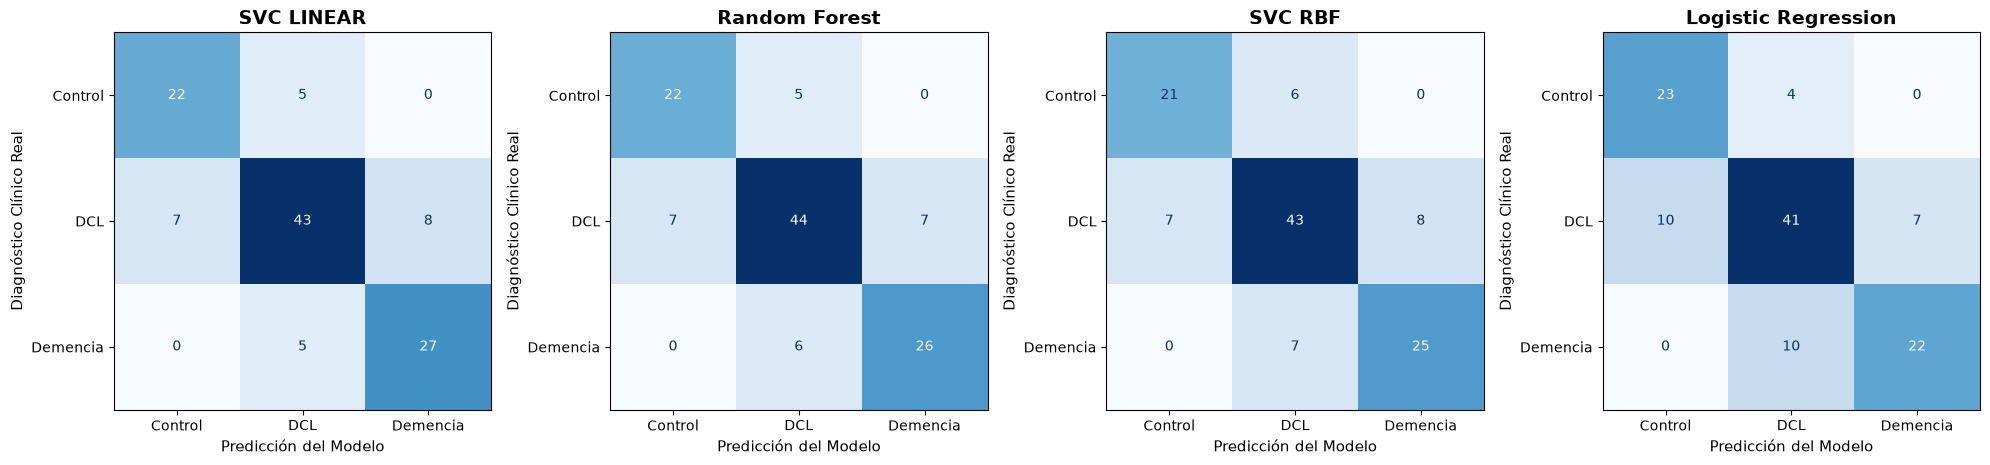

In [10]:
get_confusion_matrix(models, X_mean, y_mean, cv_kfold)

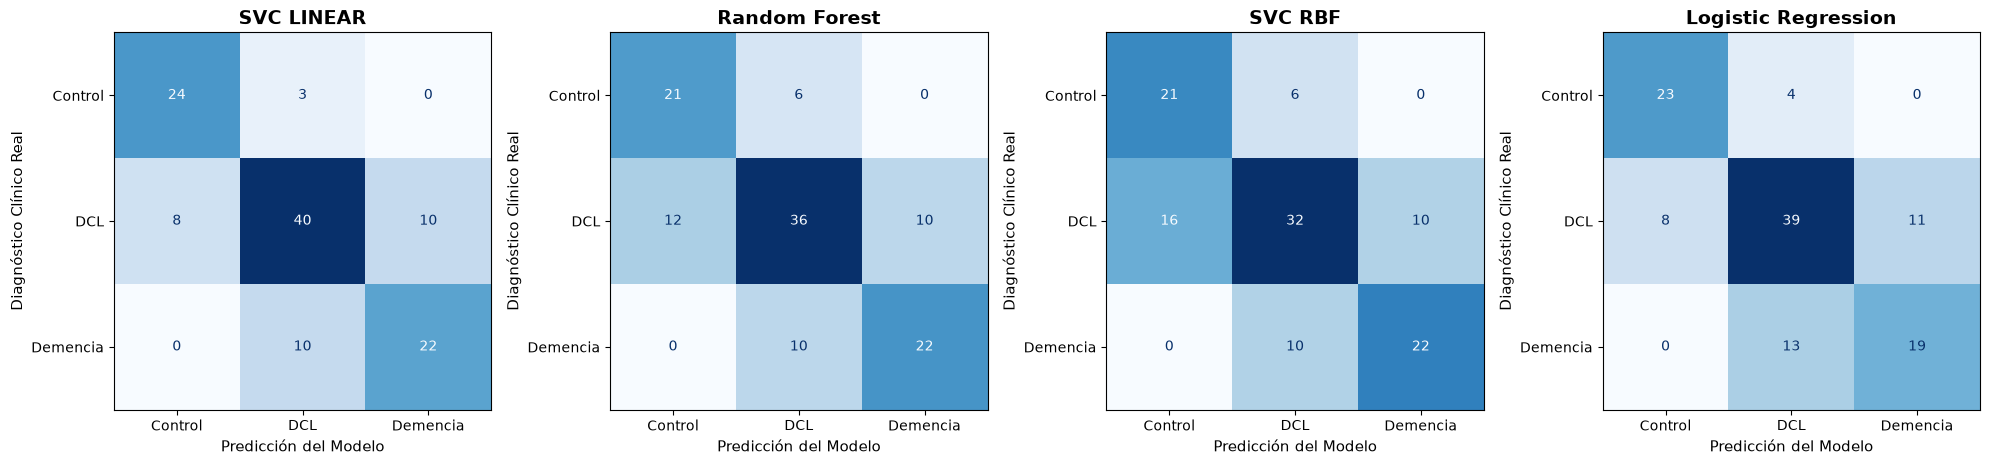

In [11]:
get_confusion_matrix(models, X_median, y_median, cv_kfold)

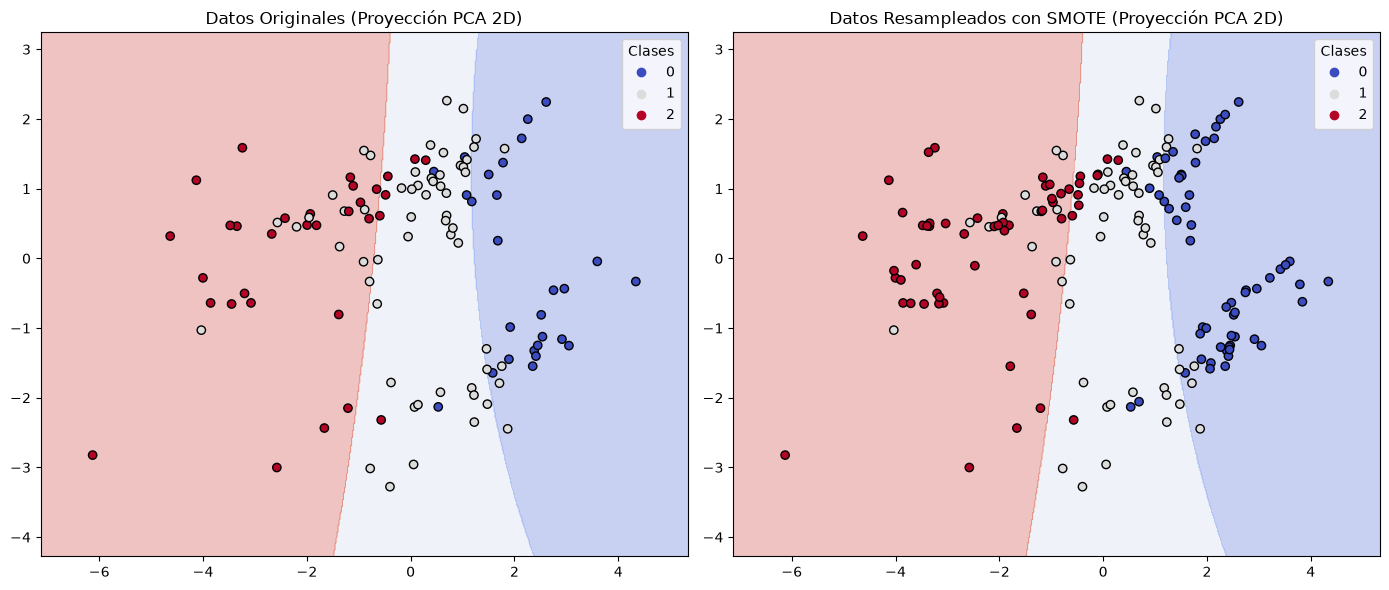

In [ ]:
from sklearn.decomposition import PCA

#Preprocesar datos
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_clean = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_clean)

#Reducir dimensiones a 2D para visualización
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#Aplicar SMOTE en el espacio reducido (o en el original y luego reducir)
smote = SMOTE(random_state=seed)
X_res, y_res = smote.fit_resample(X_scaled, y)
X_res_pca = pca.transform(X_res)

#Entrenar el clasificador en el espacio 2D para graficar la frontera
clf = models['SVC RBF']  # Usar el modelo SVC RBF como ejemplo
clf.fit(X_res_pca, y_res)

# Crear malla para la frontera de decisión
x_min, x_max = X_res_pca[:, 0].min() - 1, X_res_pca[:, 0].max() + 1
y_min, y_max = X_res_pca[:, 1].min() - 1, X_res_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Datos Originales en 2D
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
axes[0].set_title("Datos Originales (Proyección PCA 2D)")
axes[0].legend(*scatter0.legend_elements(), title="Clases")

#datos con SMOTE en 2D
axes[1].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter1 = axes[1].scatter(X_res_pca[:, 0], X_res_pca[:, 1], c=y_res, edgecolors='k', cmap=plt.cm.coolwarm)
axes[1].set_title("Datos Resampleados con SMOTE (Proyección PCA 2D)")
axes[1].legend(*scatter1.legend_elements(), title="Clases")

plt.tight_layout()
plt.show()


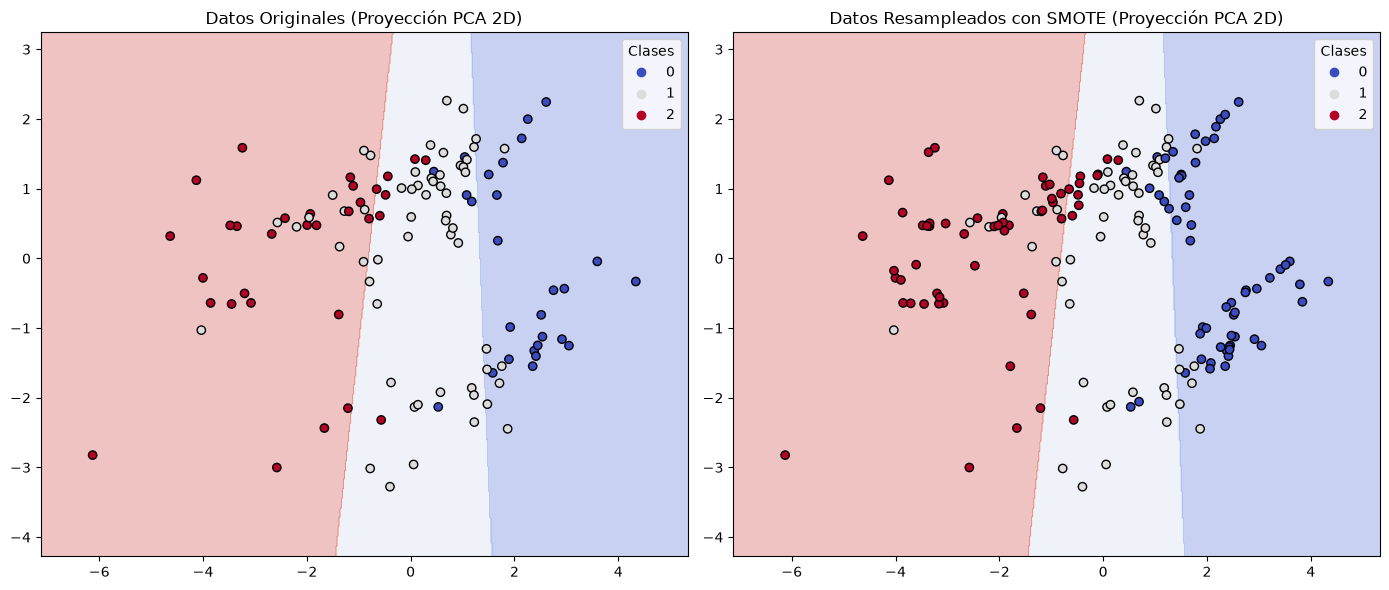

In [ ]:
#Preprocesar datos
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_clean = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_clean)

#Reducir dimensiones a 2D para visualización
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#Aplicar SMOTE en el espacio reducido (o en el original y luego reducir)
smote = SMOTE(random_state=seed)
X_res, y_res = smote.fit_resample(X_scaled, y)
X_res_pca = pca.transform(X_res)

#Entrenar el clasificador en el espacio 2D para graficar la frontera
clf = models['SVC LINEAR']  # Usar el modelo SVC RBF como ejemplo
clf.fit(X_res_pca, y_res)

# Crear malla para la frontera de decisión
x_min, x_max = X_res_pca[:, 0].min() - 1, X_res_pca[:, 0].max() + 1
y_min, y_max = X_res_pca[:, 1].min() - 1, X_res_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Datos Originales en 2D
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
axes[0].set_title("Datos Originales (Proyección PCA 2D)")
axes[0].legend(*scatter0.legend_elements(), title="Clases")

#datos con SMOTE en 2D
axes[1].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter1 = axes[1].scatter(X_res_pca[:, 0], X_res_pca[:, 1], c=y_res, edgecolors='k', cmap=plt.cm.coolwarm)
axes[1].set_title("Datos Resampleados con SMOTE (Proyección PCA 2D)")
axes[1].legend(*scatter1.legend_elements(), title="Clases")

plt.tight_layout()
plt.show()
